# Step 1 — Loading & Exploring WFDB Records

Each subject has **two** separate records:

| Record | Channels | fs | Annotations |
|---|---|---|---|
| `SubjectX_AccTempEDA` | ax, ay, az, temp, EDA | 8 Hz | yes (`.atr`) |
| `SubjectX_SpO2HR` | SpO2, hr | 1 Hz | no |

Phase labels in annotations: `Relax`, `PhysicalStress`, `EmotionalStress`, `CognitiveStress`

In [32]:
import sys
sys.path.append('..')

from src.preprocessing import load_record, get_phase_segments, subject_paths

## Load Subject 1 — both records

In [33]:
path_eda, path_hr = subject_paths(1)

rec_eda = load_record(path_eda, ann_ext='atr')   # has annotations
rec_hr  = load_record(path_hr,  ann_ext=None)    # no annotation file

for name, rec in [('AccTempEDA', rec_eda), ('SpO2HR', rec_hr)]:
    dur = rec['signal'].shape[0] / rec['fs'] / 60
    print(f"{name}")
    print(f"  channels : {rec['sig_name']}")
    print(f"  fs       : {rec['fs']} Hz")
    print(f"  shape    : {rec['signal'].shape}  (samples x channels)")
    print(f"  duration : {dur:.1f} min")
    print()

AccTempEDA
  channels : ['ax', 'ay', 'az', 'temp', 'EDA']
  fs       : 8 Hz
  shape    : (18343, 5)  (samples x channels)
  duration : 38.2 min

SpO2HR
  channels : ['SpO2', 'hr']
  fs       : 1 Hz
  shape    : (2299, 2)  (samples x channels)
  duration : 38.3 min



## Annotation timeline

In [34]:
fs = rec_eda['fs']

for sample, phase in zip(rec_eda['ann_samples'], rec_eda['ann_labels']):
    print(f"{phase}: {sample / fs:.0f}s")

Relax: 0s
PhysicalStress: 300s
Relax: 628s
EmotionalStress: 928s
CognitiveStress: 968s
Relax: 1333s
EmotionalStress: 1633s
Relax: 1993s


## Phase segments — duration per phase

In [35]:
segments = get_phase_segments(rec_eda)

print(f"{'Phase':<20}  {'Duration':>10}  {'Samples':>8}")
print('-' * 45)
for seg in segments:
    dur = seg['signal'].shape[0] / fs
    print(f"{seg['label']:<20}  {dur:>8.1f}s  {seg['signal'].shape[0]:>8}")

Phase                   Duration   Samples
---------------------------------------------
Relax                    300.0s      2400
PhysicalStress           328.1s      2625
Relax                    300.1s      2401
EmotionalStress           40.1s       321
CognitiveStress          364.1s      2913
Relax                    300.1s      2401
EmotionalStress          360.1s      2881
Relax                    300.0s      2400


## Plot all channels across all phases

Full-length signals with vertical lines at phase boundaries.

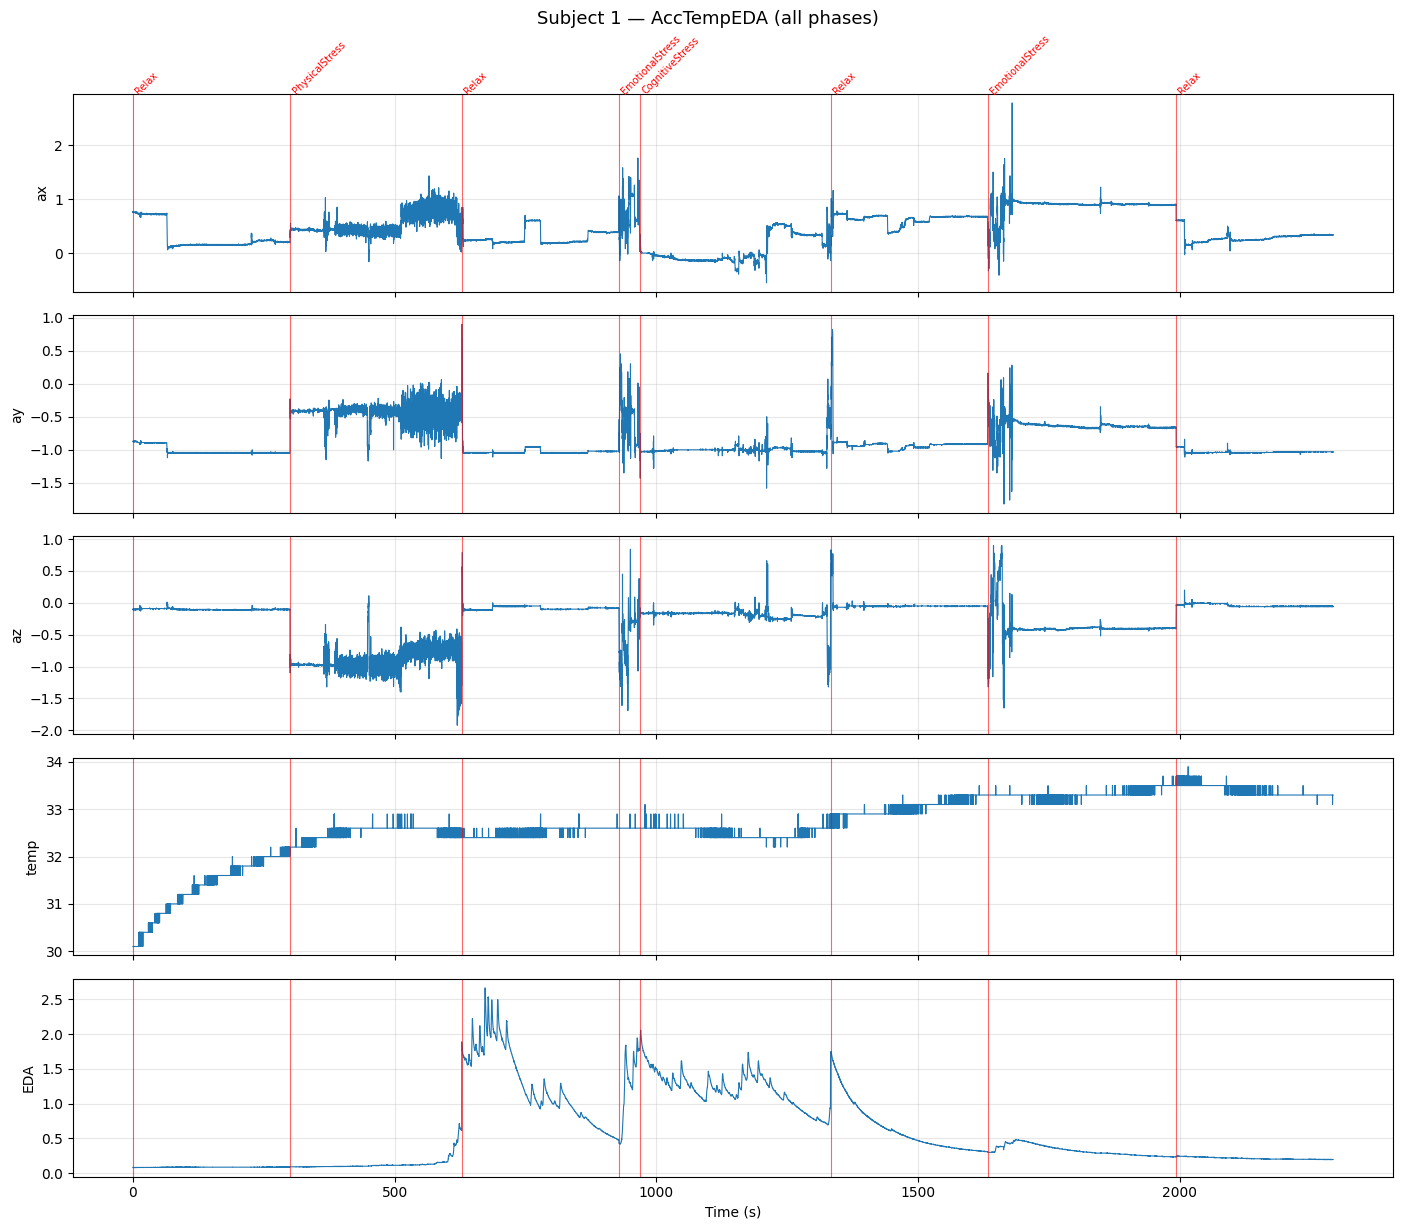

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Extract signal data and build a time axis in seconds
signals = rec_eda['signal']
channel_names = rec_eda['sig_name']
num_channels = signals.shape[1]
time_axis = np.arange(signals.shape[0]) / fs

# Convert phase boundary positions from samples to seconds
phase_times  = [sample / fs for sample in rec_eda['ann_samples']]
phase_labels = rec_eda['ann_labels']

# One subplot per channel, all sharing the same x-axis
fig, axes = plt.subplots(num_channels, 1, figsize=(14, 2.5 * num_channels), sharex=True)

for channel_idx, ax in enumerate(axes):
    # Plot the channel signal
    ax.plot(time_axis, signals[:, channel_idx], lw=0.8)

    # Draw a vertical red line at each phase boundary
    for phase_time, phase_label in zip(phase_times, phase_labels):
        ax.axvline(phase_time, color='red', lw=0.8, alpha=0.6)

        # Only label the phase on the top subplot to avoid clutter
        if channel_idx == 0:
            ax.text(phase_time + 1, ax.get_ylim()[1], phase_label,
                    fontsize=7, color='red', rotation=45)

    ax.set_ylabel(channel_names[channel_idx])
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Subject 1 — AccTempEDA (all phases)', fontsize=13)
plt.tight_layout()
plt.show()
